<a href="https://colab.research.google.com/github/alexa21342/CSCI-167/blob/CSCI-167-Assignments/10_5_Convolution_For_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Alex Cortez CSCI 167 11/5/2025

# **Notebook 10.5: Convolution for MNIST**

This notebook builds a proper network for 2D convolution.  It works with the MNIST dataset (figure 15.15a), which was the original classic dataset for classifying images.  The network will take a 28x28 grayscale image and classify it into one of 10 classes representing a digit.

The code is adapted from https://nextjournal.com/gkoehler/pytorch-mnist

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.


In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import random

In [2]:
# Run this once to load the train and test data straight into a dataloader class
# that will provide the batches

# (It may complain that some files are missing because the files seem to have been
# reorganized on the underlying website, but it still seems to work). If everything is working
# properly, then the whole notebook should run to the end without further problems
# even before you make changes.
batch_size_train = 64
batch_size_test = 1000

# ✅ Change this directory to point to an existing local directory.
# For example, create a "data" folder in your project directory:
myDir = './data'

train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(
        myDir, train=True, download=True,
        transform=torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize((0.1307,), (0.3081,))
        ])
    ),
    batch_size=batch_size_train, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(
        myDir, train=False, download=True,
        transform=torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize((0.1307,), (0.3081,))
        ])
    ),
    batch_size=batch_size_test, shuffle=True
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 524kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.66MB/s]


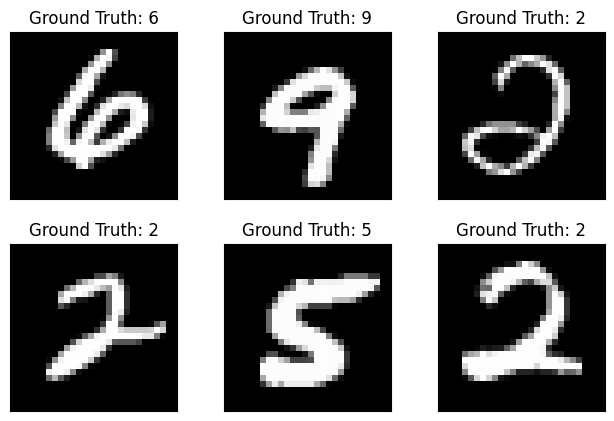

In [3]:
# Let's draw some of the training data
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
plt.show()

Define the network.  This is a more typical way to define a network than the sequential structure.  We define a class for the network, and define the parameters in the constructor.  Then we use a function called forward to actually run the network.  It's easy to see how you might use residual connections in this format.

In [4]:
from torch import nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # 1. Valid convolution with kernel size 5, 1 input channel, 10 output channels
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5)
        # 4. Valid convolution with kernel size 5, 10 input channels, 20 output channels
        self.conv2 = nn.Conv2d(in_channels=10, out_channels=20, kernel_size=5)
        # 5. 2D Dropout layer
        self.drop = nn.Dropout2d()
        # 9. Fully connected layer mapping to 50
        #    The input dimension must match the flattened output after the above layers.
        #    For MNIST (28x28 images):
        #    After conv1 (5x5 kernel, valid): 28 → 24
        #    MaxPool2d(2x2): 24 → 12
        #    After conv2 (5x5 kernel, valid): 12 → 8
        #    MaxPool2d(2x2): 8 → 4
        #    → Output size = 20 channels * 4 * 4 = 320
        self.fc1 = nn.Linear(20 * 4 * 4, 50)
        # 11. Fully connected layer mapping from 50 → 10
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        # 1–3. Conv → MaxPool(2x2) → ReLU
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        # 4–7. Conv → Dropout → MaxPool(2x2) → ReLU
        x = F.relu(F.max_pool2d(self.drop(self.conv2(x)), 2))
        # 8. Flatten
        x = torch.flatten(x, 1)
        # 9–10. Fully connected → ReLU
        x = F.relu(self.fc1(x))
        # 11–12. Fully connected → Softmax
        x = F.log_softmax(self.fc2(x), dim=1)
        return x


In [5]:
# He initialization of weights
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

In [6]:
# Create network
model = Net()
# Initialize model weights
model.apply(weights_init)
# Define optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [7]:
# Main training routine
def train(epoch):
  model.train()
  # Get each
  for batch_idx, (data, target) in enumerate(train_loader):
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()
    # Store results
    if batch_idx % 10 == 0:
      print('Train Epoch: {} [{}/{}]\tLoss: {:.6f}'.format(
        epoch, batch_idx * len(data), len(train_loader.dataset), loss.item()))

In [8]:
# Run on test data
def test():
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      output = model(data)
      test_loss += F.nll_loss(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss, correct, len(test_loader.dataset),
    100. * correct / len(test_loader.dataset)))

In [9]:
# Get initial performance
test()
# Train for three epochs
n_epochs = 3
for epoch in range(1, n_epochs + 1):
  train(epoch)
  test()

/usr/local/lib/python3.12/dist-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



Test set: Avg. loss: 2.4170, Accuracy: 1163/10000 (12%)

Train Epoch: 1 [0/60000]	Loss: 2.445035
Train Epoch: 1 [640/60000]	Loss: 2.249096
Train Epoch: 1 [1280/60000]	Loss: 2.201796
Train Epoch: 1 [1920/60000]	Loss: 2.074809
Train Epoch: 1 [2560/60000]	Loss: 1.889259
Train Epoch: 1 [3200/60000]	Loss: 1.655271
Train Epoch: 1 [3840/60000]	Loss: 1.387963
Train Epoch: 1 [4480/60000]	Loss: 1.266833
Train Epoch: 1 [5120/60000]	Loss: 1.119890
Train Epoch: 1 [5760/60000]	Loss: 1.107232
Train Epoch: 1 [6400/60000]	Loss: 0.963289
Train Epoch: 1 [7040/60000]	Loss: 0.886111
Train Epoch: 1 [7680/60000]	Loss: 1.082183
Train Epoch: 1 [8320/60000]	Loss: 0.781479
Train Epoch: 1 [8960/60000]	Loss: 0.452812
Train Epoch: 1 [9600/60000]	Loss: 0.546861
Train Epoch: 1 [10240/60000]	Loss: 0.458343
Train Epoch: 1 [10880/60000]	Loss: 0.559559
Train Epoch: 1 [11520/60000]	Loss: 0.575979
Train Epoch: 1 [12160/60000]	Loss: 0.562805
Train Epoch: 1 [12800/60000]	Loss: 0.642904
Train Epoch: 1 [13440/60000]	Loss: 0.5

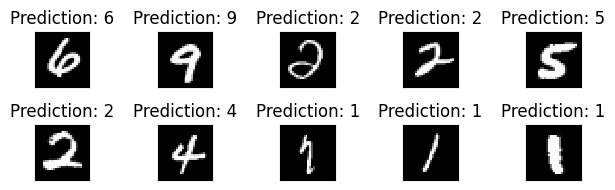

In [10]:
# Run network on data we got before and show predictions
output = model(example_data)

fig = plt.figure()
for i in range(10):
  plt.subplot(5,5,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Prediction: {}".format(
    output.data.max(1, keepdim=True)[1][i].item()))
  plt.xticks([])
  plt.yticks([])
plt.show()